In [8]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.cluster import KMeans
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage import data
from scipy import ndimage


import sys
%matplotlib inline
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
sys.path.append('/content/drive/My Drive')
image_brg = cv.imread('/content/drive/My Drive/lab5_image.jpg')
import utils

Mounted at /content/drive


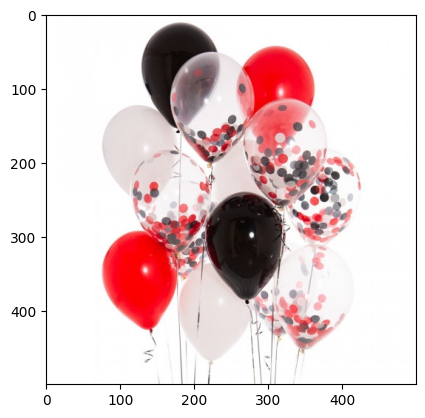

In [9]:
image_rgb = cv.cvtColor(image_brg, cv.COLOR_BGR2RGB)
image_hsv = cv.cvtColor(image_rgb, cv.COLOR_RGB2HSV)
image_gray = cv.cvtColor(image_rgb, cv.COLOR_RGB2GRAY)
plt.imshow(image_rgb)
plt.show()

/content/drive/My Drive/utils.py:41: RuntimeWarning: overflow encountered in scalar add
  similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3


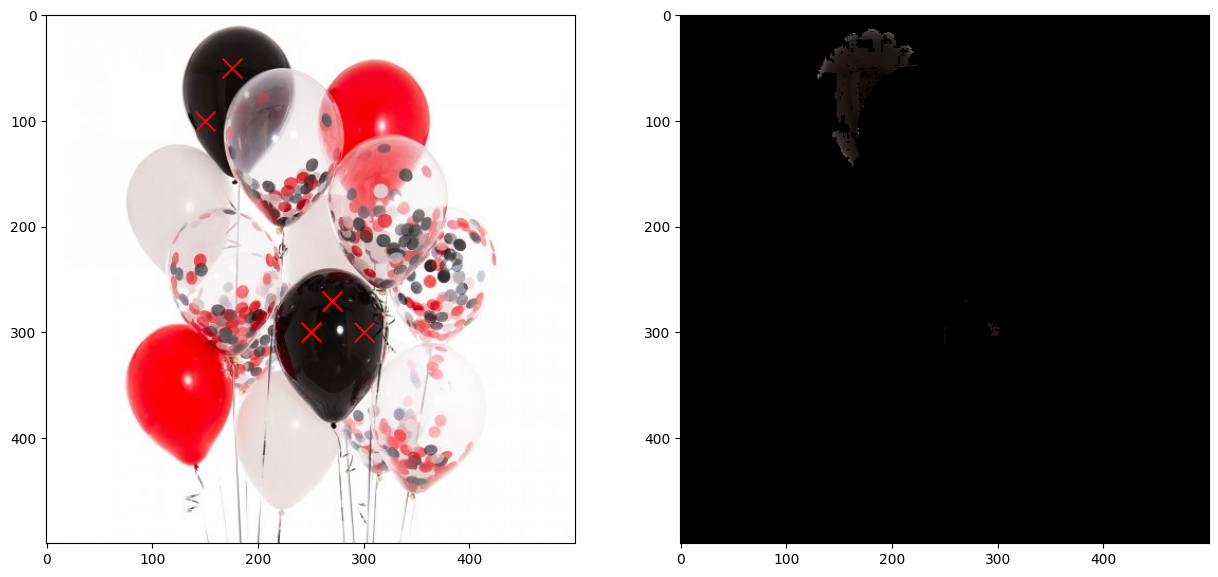

In [10]:
seeds = [(100, 150), (300 , 300), (300,250), (50,175), (270, 270)]
# координаты для графика
x = list(map(lambda x: x[1], seeds))
y = list(map(lambda x: x[0], seeds))
# порог похожести цвета региона
threshold = 20
# находим сегментацию используя метод из segmentation_utils
segmented_region = utils.region_growingHSV(image_hsv, seeds, threshold)
# накладываем маску - отображаем только участки попавшие в какой-либо сегмент
result = cv.bitwise_and(image_brg, image_brg, mask=segmented_region)
# отображаем полученное изображение
plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.scatter(x, y, marker="x", color="red", s=200)
plt.imshow(image_rgb)
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()

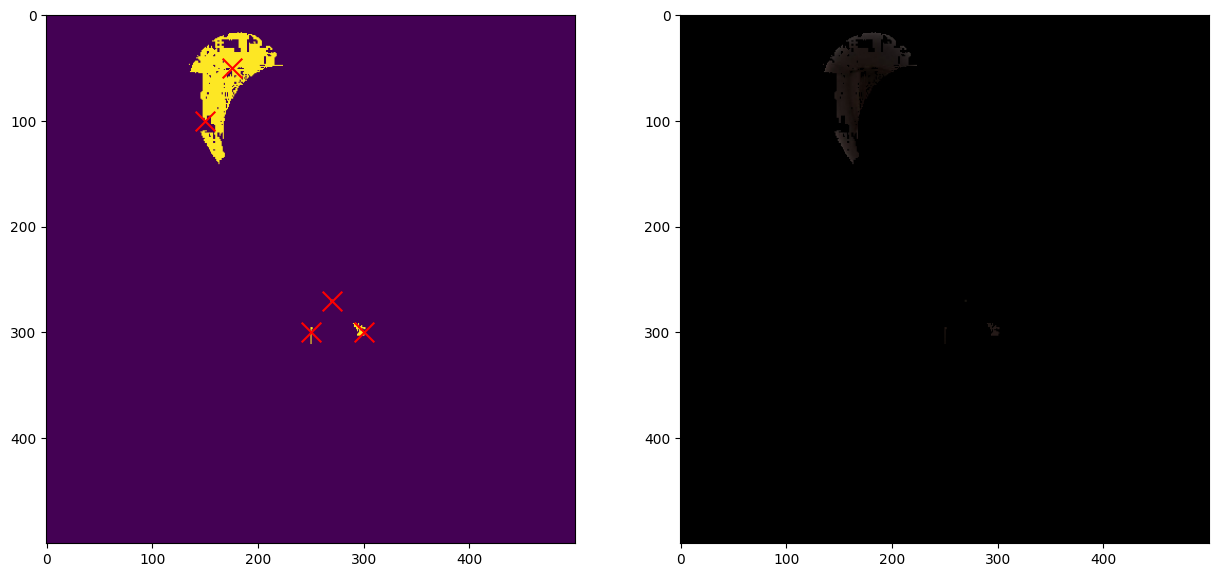

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [11]:
lower_black = np.array([0,0,10])
upper_black = np.array([180,255,60])

mask = cv.inRange(result, lower_black, upper_black)
result123 = cv.bitwise_and(result, result, mask=mask)

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.scatter(x, y, marker="x", color="red", s=200)
plt.imshow(mask)
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result123, cv.COLOR_BGR2RGB))
plt.show()
print(mask)

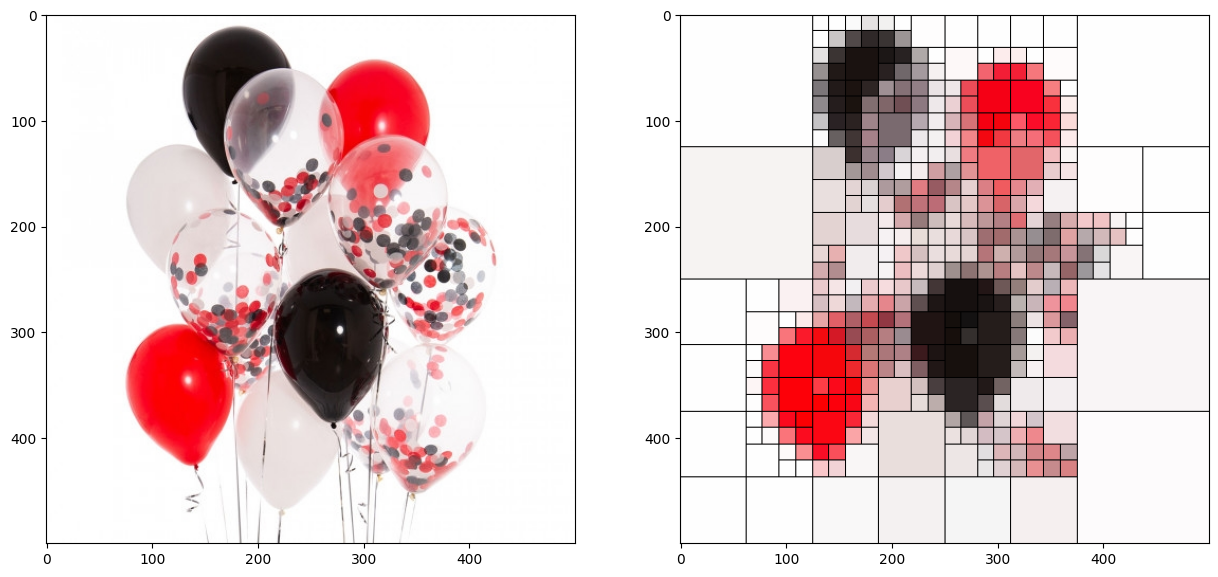

In [13]:
qt = utils.QTree(stdThreshold = 3, minPixelSize = 9,img = image_brg.copy())
qt.subdivide()
tree_image = qt.render_img(thickness=1, color=(0,0,0))

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(tree_image, cv.COLOR_BGR2RGB))
plt.show()

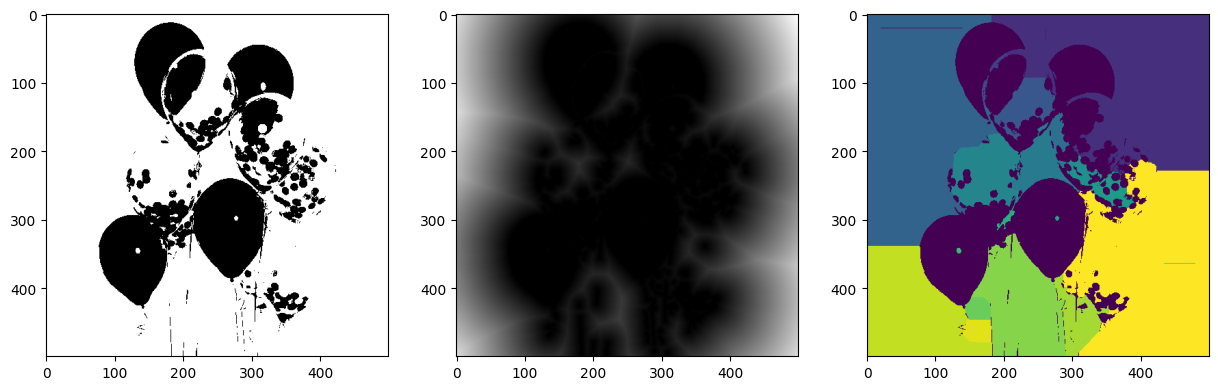

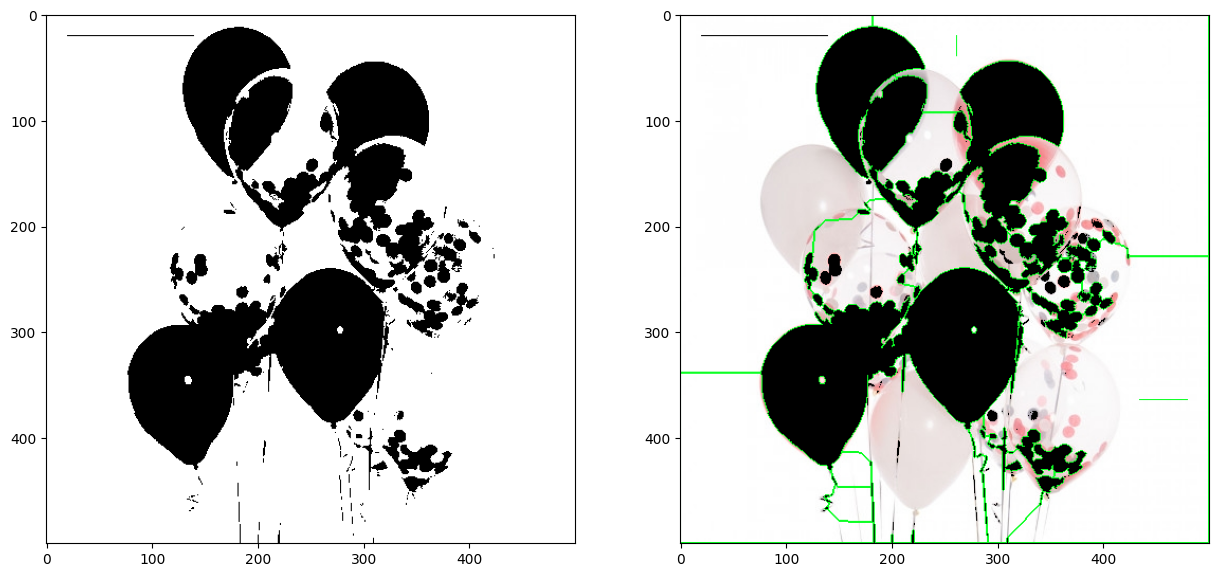

In [14]:
# Алгоритм водораздела
# Бинаризируем изображение
binary_image = cv.threshold(image_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)[1]
# Определяем карту расстояний
distance_map = ndimage.distance_transform_edt(binary_image)
# Определяем локальные максимумы (получаем координаты точек)
local_max = peak_local_max(distance_map, min_distance=20, labels=binary_image)

# Создаем маску тех же размеров, что и исходное изображение
mask_local_max = np.zeros_like(binary_image, dtype=bool)

# Помечаем локальные максимумы на маске
mask_local_max[tuple(local_max.T)] = True

# Присваиваем метки и продолжаем алгоритм
markers = ndimage.label(mask_local_max, structure=np.ones((3, 3)))[0]
labels = watershed(-distance_map, markers, mask=binary_image)

# построим результаты работы алгоритма
plt.figure(figsize=(15,20))
plt.subplot(1, 3, 1)
plt.imshow(binary_image, cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(np.uint8(distance_map + 50), cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(np.uint8(labels))
plt.show()

# Найдем границы контуров и положим в маску все кроме метки 0
mask1 = np.zeros(image_brg.shape[0:2], dtype="uint8")
total_area = 0
for label in np.unique(labels):
    if label < 2:
        continue
    # Create a mask
    mask = np.zeros(image_gray.shape, dtype="uint8")
    mask[labels == label] = 255
    mask1 = mask1 + mask

    # Find contours and determine contour area
    cnts = cv.findContours(mask.copy(), cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    c = max(cnts, key=cv.contourArea)
    area = cv.contourArea(c)
    total_area += area
    cv.drawContours(image_brg, [c], -1, (36,255,12), 1)

result = cv.bitwise_and(image_brg, image_brg, mask=mask1)

plt.figure(figsize=(15,20))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()

[[214]
 [ 51]
 [131]
 [253]]
[[253 253 253 ... 253 253 253]
 [253 253 253 ... 253 253 253]
 [253 253 253 ... 253 253 253]
 ...
 [253 253 253 ... 253 253 253]
 [253 253 253 ... 253 253 253]
 [253 253 253 ... 253 253 253]]


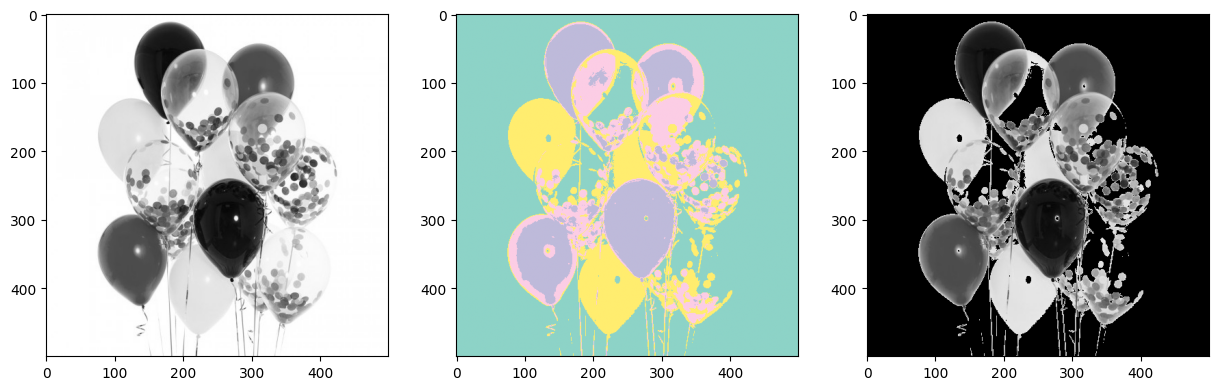

In [19]:
# Преобразуем изображение в оттенках серого в одномерный массив
pixels = image_gray.reshape(-1, 1)
# Задаем число кластеров для сегментации
K = 4
# С помощью библиотеки sklearn.cluster import KMeans проводим кластеризацию по яркости
kmeans = KMeans(n_clusters=K, random_state=0)
labels = kmeans.fit_predict(pixels)
cluster_centers = kmeans.cluster_centers_
print (np.uint8(cluster_centers))
# Каждому пикселю назначаем значение из центра кластера
segments = np.uint8(cluster_centers[labels].reshape(image_gray.shape))
print(segments)
# Удалим самые яркие пиксели
segments[segments==253] = 0
result = cv.bitwise_and(image_gray, image_gray, mask=segments)
# Отобразим избражения
plt.figure(figsize=(15,20))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(image_gray, cv.COLOR_BGR2RGB))
plt.subplot(1, 3, 2)
plt.imshow(segments, cmap='Set3')
plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()

Number of segments:  6


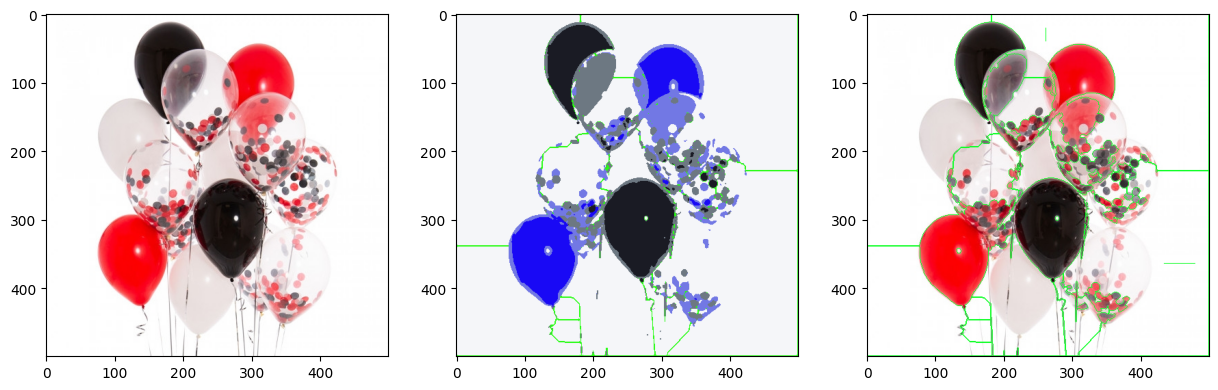

In [20]:
## Методы кластеризации. Сдвиг среднего (Mean shift)
#Сглаживаем чтобы уменьшить шум
blur_image = cv.medianBlur(image_brg, 3)
# Выстраиваем пиксели в один ряд и переводим в формат с правающей точкой
flat_image = np.float32(blur_image.reshape((-1,3)))

# Используем meanshift из библиотеки sklearn
bandwidth = estimate_bandwidth(flat_image, quantile=.2, n_samples=3000)
ms = MeanShift(bandwidth=bandwidth, max_iter=800, bin_seeding=True)
ms.fit(flat_image)
labeled = ms.labels_

# получим количество сегментов
segments = np.unique(labeled)
print('Number of segments: ', segments.shape[0])

# получим средний цвет сегмента
total = np.zeros((segments.shape[0], 3), dtype=float)
count = np.zeros(total.shape, dtype=float)
for i, label in enumerate(labeled):
    total[label] = total[label] + flat_image[i]
    count[label] += 1
avg = total/count
avg = np.uint8(avg)
# Для каждого пискеля проставим средний цвет его сегмента
mean_shift_image = avg[labeled].reshape((image_brg.shape))
# Маской скроем один из сегментов
mask1 = mean_shift_image[:,:,0]
mask1[mask1==89] = 0
mean_shift_with_mask_image = cv.bitwise_and(image_brg, image_brg, mask=mask1)
# Построим изображение
plt.figure(figsize=(15,20))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.subplot(1, 3, 2)
plt.imshow(mean_shift_image, cmap='Set3')
plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(mean_shift_with_mask_image, cv.COLOR_BGR2RGB))
plt.show()